# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Ferdana Al-Hakim  
**NIM:** 122140012

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('results_ws4', exist_ok=True)
os.makedirs('assets_ws4', exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


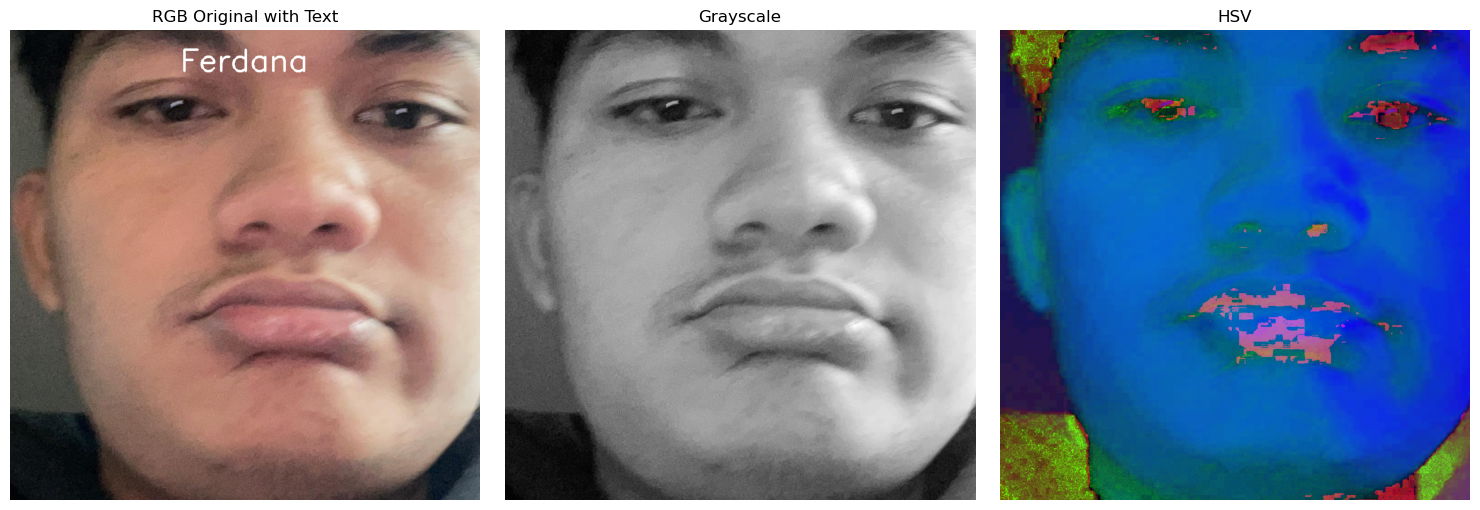

Original image shape: (3664, 2062, 3)
Face crop coordinates: (516, 1317) to (1546, 2347)
Face crop resized: (920, 920, 3)
Background crop resized: (920, 920, 3)


In [2]:
img = cv2.imread(os.path.join('assets_ws4', 'image1.jpg'))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

height, width = img_rgb.shape[:2]

center_x = width // 2
center_y = height // 2

face_size = min(width, height) // 2
face_x1 = center_x - face_size // 2
face_y1 = center_y - face_size // 2
face_x2 = center_x + face_size // 2
face_y2 = center_y + face_size // 2
face_crop = img_rgb[face_y1:face_y2, face_x1:face_x2]

bg_width = width // 3
bg_height = height // 2
bg_x1 = 0
bg_y1 = 0
bg_x2 = bg_width
bg_y2 = bg_height
bg_crop = img_rgb[bg_y1:bg_y2, bg_x1:bg_x2]

face_resized = cv2.resize(face_crop, (920, 920))
bg_resized = cv2.resize(bg_crop, (920, 920))

face_gray = cv2.cvtColor(face_resized, cv2.COLOR_RGB2GRAY)
face_hsv = cv2.cvtColor(face_resized, cv2.COLOR_RGB2HSV)

face_with_text = face_resized.copy()

text = 'Ferdana'
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 2
thickness = 3
color = (255, 255, 255)

text_size = cv2.getTextSize(text, font, font_scale, thickness)[0]
text_x = (920 - text_size[0]) // 2
text_y = 80

cv2.putText(face_with_text, text, (text_x, text_y), 
            font, font_scale, color, thickness)

cv2.imwrite(os.path.join('results_ws4', 'face_crop_920x920.png'), cv2.cvtColor(face_with_text, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join('results_ws4', 'bg_crop_920x920.png'), cv2.cvtColor(bg_resized, cv2.COLOR_RGB2BGR))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(face_with_text)
axes[0].set_title('RGB Original with Text')
axes[0].axis('off')

axes[1].imshow(face_gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(face_hsv)
axes[2].set_title('HSV')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join('results_ws4', 'soal1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Original image shape: {img_rgb.shape}")
print(f"Face crop coordinates: ({face_x1}, {face_y1}) to ({face_x2}, {face_y2})")
print(f"Face crop resized: {face_resized.shape}")
print(f"Background crop resized: {bg_resized.shape}")

#### Penjelasan Soal 1

**Efek Cropping:**
Cropping memungkinkan kita untuk memfokuskan area tertentu dari gambar dengan memotong region of interest (ROI). Pada kasus ini, saya melakukan dua jenis cropping:
- Cropping kotak persegi pada area wajah untuk mengisolasi subjek utama
- Cropping persegi panjang pada area latar belakang untuk mengambil konteks visual sekitar

Setelah di-resize menjadi 920x920 piksel, kedua hasil crop memiliki dimensi yang seragam dan siap untuk pemrosesan lebih lanjut.

**Perubahan Ruang Warna:**
- **RGB**: Representasi warna standar dengan 3 channel (Red, Green, Blue) yang menunjukkan kombinasi intensitas warna primer
- **Grayscale**: Konversi ke satu channel dengan nilai intensitas 0-255, menghilangkan informasi warna dan hanya mempertahankan luminance
- **HSV**: Ruang warna yang memisahkan Hue (warna), Saturation (kejenuhan), dan Value (kecerahan), lebih intuitif untuk manipulasi warna tertentu

Konversi ke grayscale berguna untuk analisis struktur dan tekstur tanpa gangguan warna, sedangkan HSV memudahkan segmentasi berdasarkan warna spesifik.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


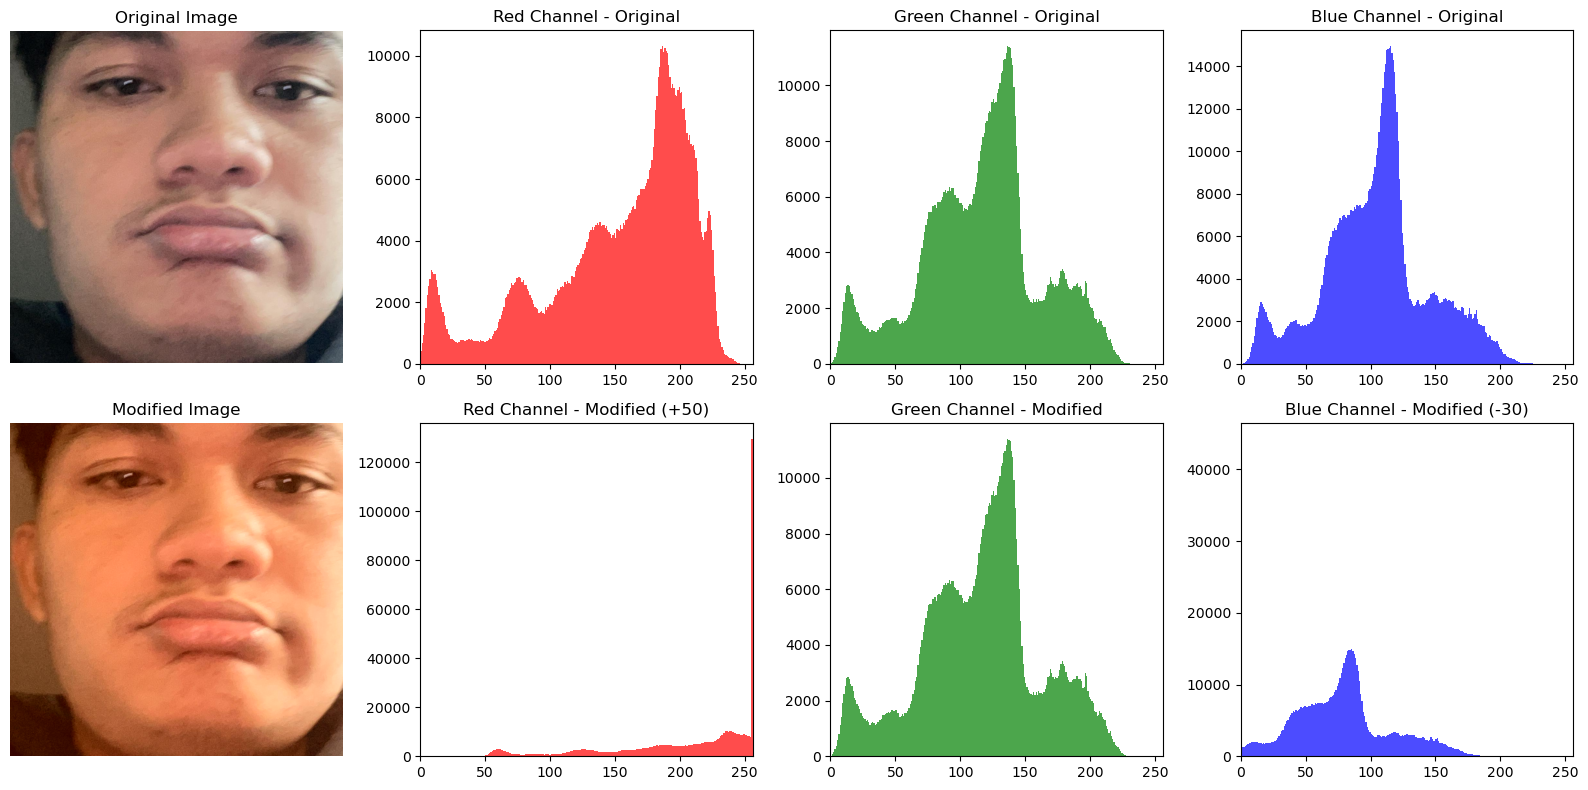

Channel modification completed
Red channel increase: +50
Blue channel decrease: -30


In [3]:
img_original = face_resized.copy()

r, g, b = cv2.split(img_original)

r_modified = np.clip(r.astype(np.int16) + 50, 0, 255).astype(np.uint8)
b_modified = np.clip(b.astype(np.int16) - 30, 0, 255).astype(np.uint8)

img_modified = cv2.merge([r_modified, g, b_modified])

cv2.imwrite(os.path.join('results_ws4', 'soal2_rgb_modified.png'), cv2.cvtColor(img_modified, cv2.COLOR_RGB2BGR))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(img_original)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(r.ravel(), bins=256, color='red', alpha=0.7, range=(0, 256))
axes[0, 1].set_title('Red Channel - Original')
axes[0, 1].set_xlim([0, 256])

axes[0, 2].hist(g.ravel(), bins=256, color='green', alpha=0.7, range=(0, 256))
axes[0, 2].set_title('Green Channel - Original')
axes[0, 2].set_xlim([0, 256])

axes[0, 3].hist(b.ravel(), bins=256, color='blue', alpha=0.7, range=(0, 256))
axes[0, 3].set_title('Blue Channel - Original')
axes[0, 3].set_xlim([0, 256])

axes[1, 0].imshow(img_modified)
axes[1, 0].set_title('Modified Image')
axes[1, 0].axis('off')

axes[1, 1].hist(r_modified.ravel(), bins=256, color='red', alpha=0.7, range=(0, 256))
axes[1, 1].set_title('Red Channel - Modified (+50)')
axes[1, 1].set_xlim([0, 256])

axes[1, 2].hist(g.ravel(), bins=256, color='green', alpha=0.7, range=(0, 256))
axes[1, 2].set_title('Green Channel - Modified')
axes[1, 2].set_xlim([0, 256])

axes[1, 3].hist(b_modified.ravel(), bins=256, color='blue', alpha=0.7, range=(0, 256))
axes[1, 3].set_title('Blue Channel - Modified (-30)')
axes[1, 3].set_xlim([0, 256])

plt.tight_layout()
plt.savefig(os.path.join('results_ws4', 'soal2_histogram_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Channel modification completed")
print(f"Red channel increase: +50")
print(f"Blue channel decrease: -30")

#### Penjelasan Soal 2

**Dampak Manipulasi Channel RGB:**

Manipulasi intensitas channel warna menghasilkan perubahan signifikan pada persepsi warna gambar:

1. **Peningkatan Red Channel (+50):**
   - Menambahkan bias warna merah pada keseluruhan gambar
   - Gambar terlihat lebih warm-toned dengan dominasi warna kemerahan
   - Histogram red channel bergeser ke kanan menunjukkan peningkatan intensitas
   - Beberapa nilai mencapai saturasi di 255 (clipping)

2. **Penurunan Blue Channel (-30):**
   - Mengurangi komponen warna biru dari gambar
   - Menghasilkan efek yellow-tinted karena berkurangnya cool tone
   - Histogram blue channel bergeser ke kiri menunjukkan penurunan intensitas
   - Nilai minimum terpotong di 0 untuk mencegah underflow

3. **Efek Kombinasi:**
   - Kombinasi peningkatan red dan penurunan blue menghasilkan shift warna ke arah warm orange-red
   - Skin tone terlihat lebih kemerahan dan hangat
   - Teknik ini sering digunakan dalam color grading untuk menciptakan mood tertentu

Penggunaan `np.clip()` memastikan nilai tetap dalam range valid 0-255 untuk tipe data uint8.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


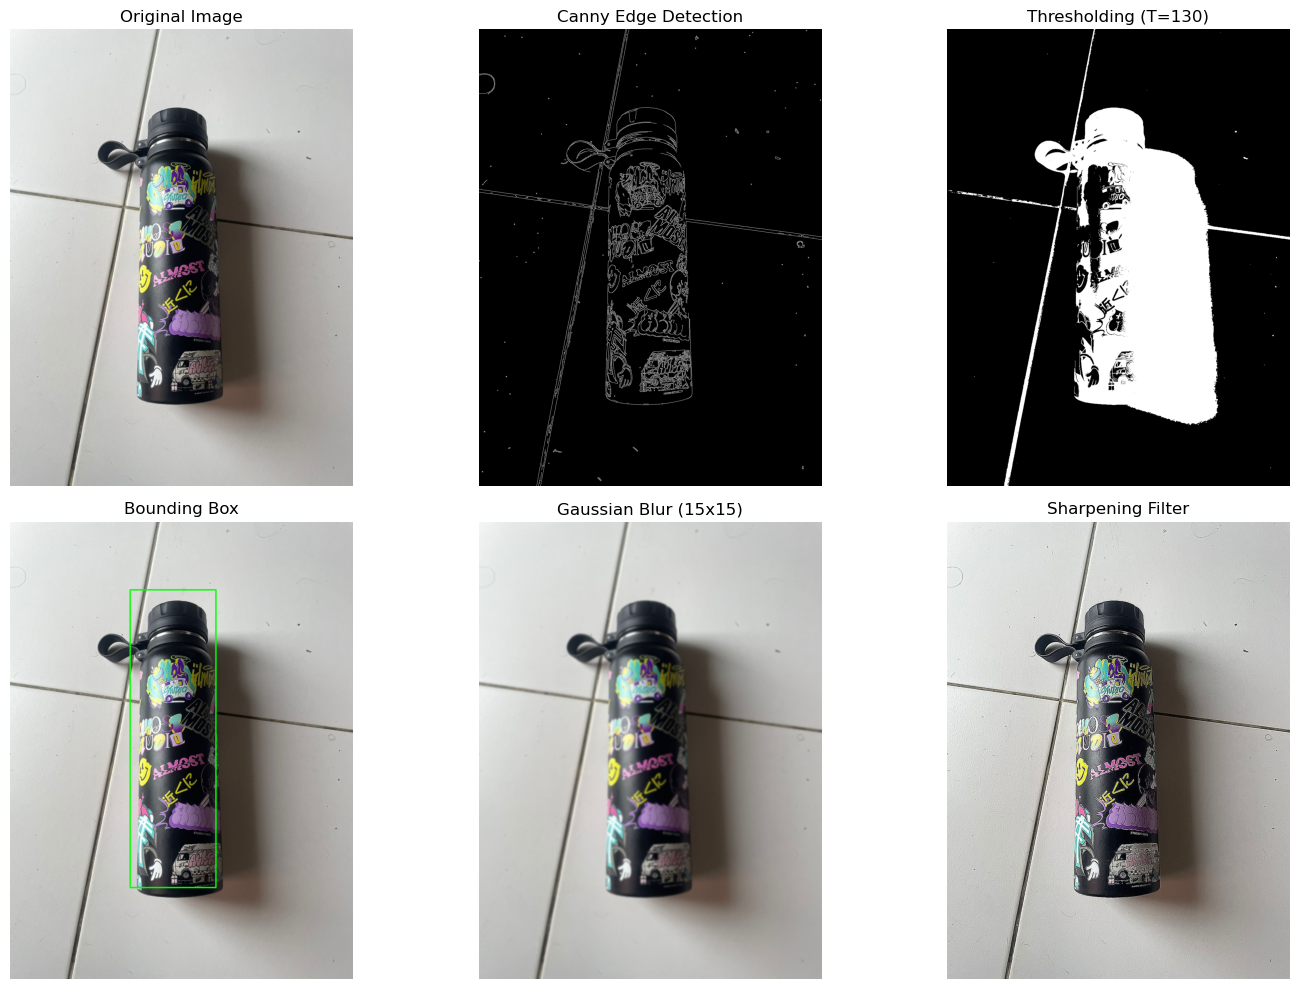

Image size: 1200x1600
Bounding box coordinates: x=420, y=240, w=300, h=1040


In [4]:
img_object = cv2.imread(os.path.join('assets_ws4', 'image2.jpg'))
img_object_rgb = cv2.cvtColor(img_object, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_object, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(img_gray, 50, 150)

_, thresh = cv2.threshold(img_gray, 130, 255, cv2.THRESH_BINARY_INV)

h_img, w_img = img_gray.shape

x = int(w_img * 0.35)
y = int(h_img * 0.15)
w = int(w_img * 0.25)
h = int(h_img * 0.65)

img_bbox = img_object_rgb.copy()
cv2.rectangle(img_bbox, (x, y), (x+w, y+h), (0, 255, 0), 3)

blur = cv2.GaussianBlur(img_object_rgb, (15, 15), 0)

kernel_sharpen = np.array([[-1, -1, -1],
                           [-1,  9, -1],
                           [-1, -1, -1]])
sharpened = cv2.filter2D(img_object_rgb, -1, kernel_sharpen)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img_object_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges, cmap='gray')
axes[0, 1].set_title('Canny Edge Detection')
axes[0, 1].axis('off')

axes[0, 2].imshow(thresh, cmap='gray')
axes[0, 2].set_title('Thresholding (T=130)')
axes[0, 2].axis('off')

axes[1, 0].imshow(img_bbox)
axes[1, 0].set_title('Bounding Box')
axes[1, 0].axis('off')

axes[1, 1].imshow(blur)
axes[1, 1].set_title('Gaussian Blur (15x15)')
axes[1, 1].axis('off')

axes[1, 2].imshow(sharpened)
axes[1, 2].set_title('Sharpening Filter')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join('results_ws4', 'soal3_edge_filter_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

cv2.imwrite(os.path.join('results_ws4', 'soal3_canny_edges.png'), edges)
cv2.imwrite(os.path.join('results_ws4', 'soal3_threshold.png'), thresh)
cv2.imwrite(os.path.join('results_ws4', 'soal3_bbox.png'), cv2.cvtColor(img_bbox, cv2.COLOR_RGB2BGR))

print(f"Image size: {w_img}x{h_img}")
print(f"Bounding box coordinates: x={x}, y={y}, w={w}, h={h}")

#### Penjelasan Soal 3

**Analisis Deteksi Tepi dan Filter:**

1. **Canny Edge Detection:**
   - Algoritma Canny mendeteksi tepi berdasarkan gradien intensitas dengan threshold ganda (50, 150)
   - Menghasilkan outline objek yang jelas dengan menekan noise melalui Gaussian smoothing internal
   - Efektif untuk mengidentifikasi batas-batas objek utama dan detail tekstur background

2. **Thresholding (T=130):**
   - Binary inverse thresholding memisahkan objek gelap dari background terang
   - Nilai threshold 130 dipilih berdasarkan distribusi intensitas untuk memaksimalkan separasi objek-background
   - Menghasilkan mask binary yang dapat digunakan untuk segmentasi lebih lanjut

3. **Bounding Box:**
   - Dibuat secara manual dengan estimasi proporsional terhadap dimensi gambar
   - Koordinat ditentukan berdasarkan posisi visual objek botol (35% x, 15% y dari ukuran gambar)
   - Pendekatan manual dipilih karena lebih reliable untuk objek dengan background kompleks

4. **Perbandingan Filter:**
   - **Gaussian Blur (15x15):** Mengurangi detail dan noise dengan merata-ratakan piksel tetangga, menghasilkan efek smooth dan soft focus. Detail halus hilang tetapi struktur besar tetap terlihat.
   - **Sharpening Filter:** Meningkatkan kontras pada tepi menggunakan kernel konvolusi yang memperkuat perbedaan intensitas. Detail dan tekstur menjadi lebih tajam dan jelas, tetapi noise juga ikut diperkuat.

Kedua filter memiliki efek berlawanan: blur menghilangkan detail sementara sharpening memperkuatnya.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

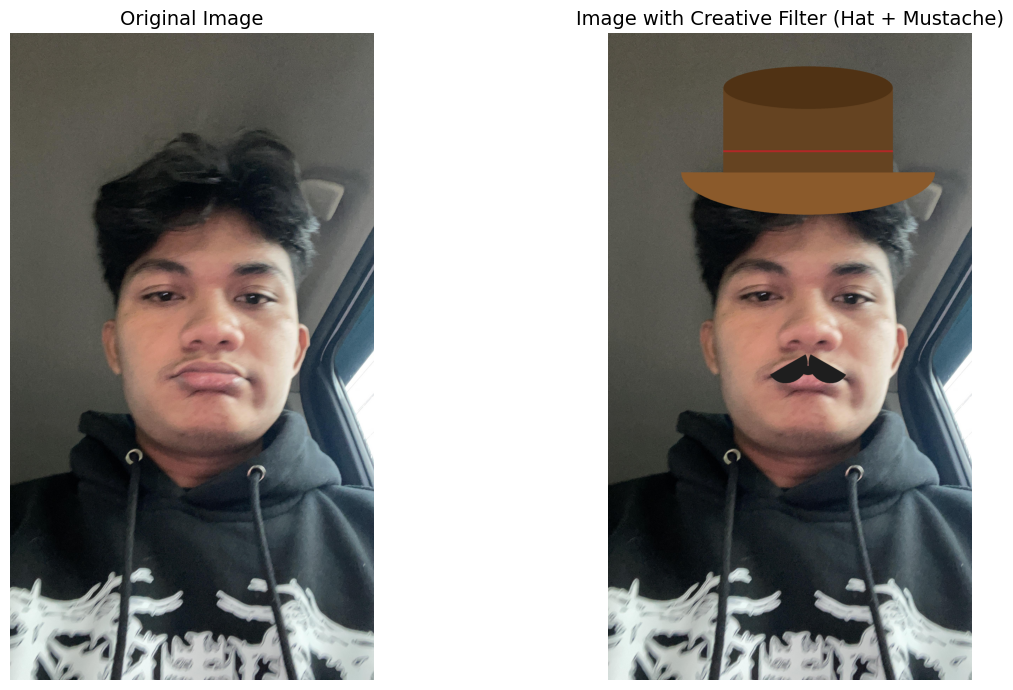

Face detection using OpenCV Haar Cascade
Eye distance: 514px
Face height: 1287px
Creative filter applied: Vintage Hat + Handlebar Mustache


In [5]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

img_face = cv2.imread(os.path.join('assets_ws4', 'image1.jpg'))
img_face_rgb = cv2.cvtColor(img_face, cv2.COLOR_BGR2RGB)
h, w, _ = img_face_rgb.shape

img_with_filter = img_face_rgb.copy()

gray = cv2.cvtColor(img_face, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

if len(faces) > 0:
    x_face, y_face, w_face, h_face = faces[0]
    
    forehead_x = x_face + w_face // 2
    forehead_y = y_face + int(h_face * 0.15)
    
    nose_x = x_face + w_face // 2
    nose_y = y_face + int(h_face * 0.65)
    
    eye_left_x = x_face + int(w_face * 0.3)
    eye_left_y = y_face + int(h_face * 0.35)
    eye_right_x = x_face + int(w_face * 0.7)
    eye_right_y = y_face + int(h_face * 0.35)
    
    eye_distance = int(w_face * 0.4)
    face_height = h_face
else:
    forehead_x = w // 2
    forehead_y = h // 3
    nose_x = w // 2
    nose_y = int(h * 0.5)
    eye_left_x = int(w * 0.4)
    eye_left_y = int(h * 0.4)
    eye_right_x = int(w * 0.6)
    eye_right_y = int(h * 0.4)
    eye_distance = 200
    face_height = 400

hat_width = int(eye_distance * 2.8)
hat_height = int(hat_width * 0.5)
hat_x = forehead_x - hat_width // 2
hat_y = forehead_y - hat_height - int(eye_distance * 0.3)

brim_height = hat_height // 3
crown_height = hat_height - brim_height

cv2.ellipse(img_with_filter, 
           (forehead_x, hat_y + crown_height), 
           (hat_width // 2, brim_height), 
           0, 0, 180, (139, 90, 43), -1)

cv2.rectangle(img_with_filter, 
             (hat_x + hat_width // 6, hat_y), 
             (hat_x + 5 * hat_width // 6, hat_y + crown_height), 
             (101, 67, 33), -1)

cv2.ellipse(img_with_filter, 
           (forehead_x, hat_y), 
           (hat_width // 3, crown_height // 4), 
           0, 0, 360, (80, 50, 20), -1)

ribbon_y = hat_y + int(crown_height * 0.75)
cv2.rectangle(img_with_filter,
             (hat_x + hat_width // 6, ribbon_y - 5),
             (hat_x + 5 * hat_width // 6, ribbon_y + 5),
             (180, 40, 40), -1)

mustache_width = int(eye_distance * 0.9)
mustache_height = int(eye_distance * 0.2)
mustache_y = nose_y + int(eye_distance * 0.15)

cv2.ellipse(img_with_filter, 
           (nose_x - mustache_width // 4, mustache_y - mustache_height // 4), 
           (mustache_width // 4, mustache_height), 
           -30, 0, 180, (30, 30, 30), -1)

cv2.ellipse(img_with_filter, 
           (nose_x + mustache_width // 4, mustache_y - mustache_height // 4), 
           (mustache_width // 4, mustache_height), 
           30, 0, 180, (30, 30, 30), -1)

cv2.ellipse(img_with_filter,
           (nose_x, mustache_y - mustache_height // 6),
           (mustache_width // 8, mustache_height // 2),
           0, 0, 180, (30, 30, 30), -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img_face_rgb)
axes[0].set_title('Original Image', fontsize=14)
axes[0].axis('off')

axes[1].imshow(img_with_filter)
axes[1].set_title('Image with Creative Filter (Hat + Mustache)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join('results_ws4', 'soal4_face_filter_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

cv2.imwrite(os.path.join('results_ws4', 'soal4_filtered_face.png'), cv2.cvtColor(img_with_filter, cv2.COLOR_RGB2BGR))

print("Face detection using OpenCV Haar Cascade")
print(f"Eye distance: {eye_distance}px")
print(f"Face height: {face_height}px")
print("Creative filter applied: Vintage Hat + Handlebar Mustache")

#### Penjelasan Soal 4

**Implementasi Face Detection dan Creative Filter:**

1. **Deteksi Wajah dengan OpenCV Haar Cascade:**
   - Menggunakan pre-trained Haar Cascade classifier dari OpenCV untuk mendeteksi wajah
   - Algoritma bekerja dengan mencari pola fitur Haar dalam gambar grayscale
   - Parameter detectMultiScale(1.1, 5) menentukan scale factor dan minimum neighbors untuk akurasi deteksi
   - Dari hasil deteksi, diekstrak koordinat wajah (x, y, width, height)

2. **Perhitungan Posisi Overlay:**
   
   **Topi (Hat):**
   - Posisi: Dihitung dari tengah atas wajah (forehead) yang diestimasi 15% dari tinggi wajah
   - Ukuran: Proporsional terhadap lebar wajah (2.8x jarak mata estimasi)
   - Digambar menggunakan kombinasi ellipse untuk brim dan rectangle untuk crown
   - Detail tambahan: ribbon band di tengah untuk estetika vintage
   
   **Kumis (Mustache):**
   - Posisi: Di bawah hidung yang diestimasi 65% dari tinggi wajah
   - Ukuran: 90% dari jarak mata untuk proporsi yang natural
   - Style handlebar mustache dibuat dengan 3 ellipse (kiri, kanan, tengah)
   - Rotasi -30° dan +30° pada sisi kiri-kanan untuk efek melengkung ke atas

3. **Tantangan Implementasi:**
   - **Estimasi landmark:** Haar Cascade hanya memberikan bounding box wajah, bukan landmark detail seperti MediaPipe, jadi posisi mata/hidung harus diestimasi dengan proporsi
   - **Scaling proporsional:** Semua overlay di-scale relatif terhadap ukuran wajah yang terdeteksi agar konsisten di berbagai resolusi gambar
   - **Fallback handling:** Ada kondisi else jika wajah tidak terdeteksi, menggunakan estimasi tengah gambar
   - **Drawing order:** Urutan menggambar shape penting agar hasilnya terlihat natural (brim dulu, baru crown)

Filter ini mendemonstrasikan bagaimana face detection sederhana bisa digunakan untuk membuat creative filters dengan estimasi proporsi wajah.

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

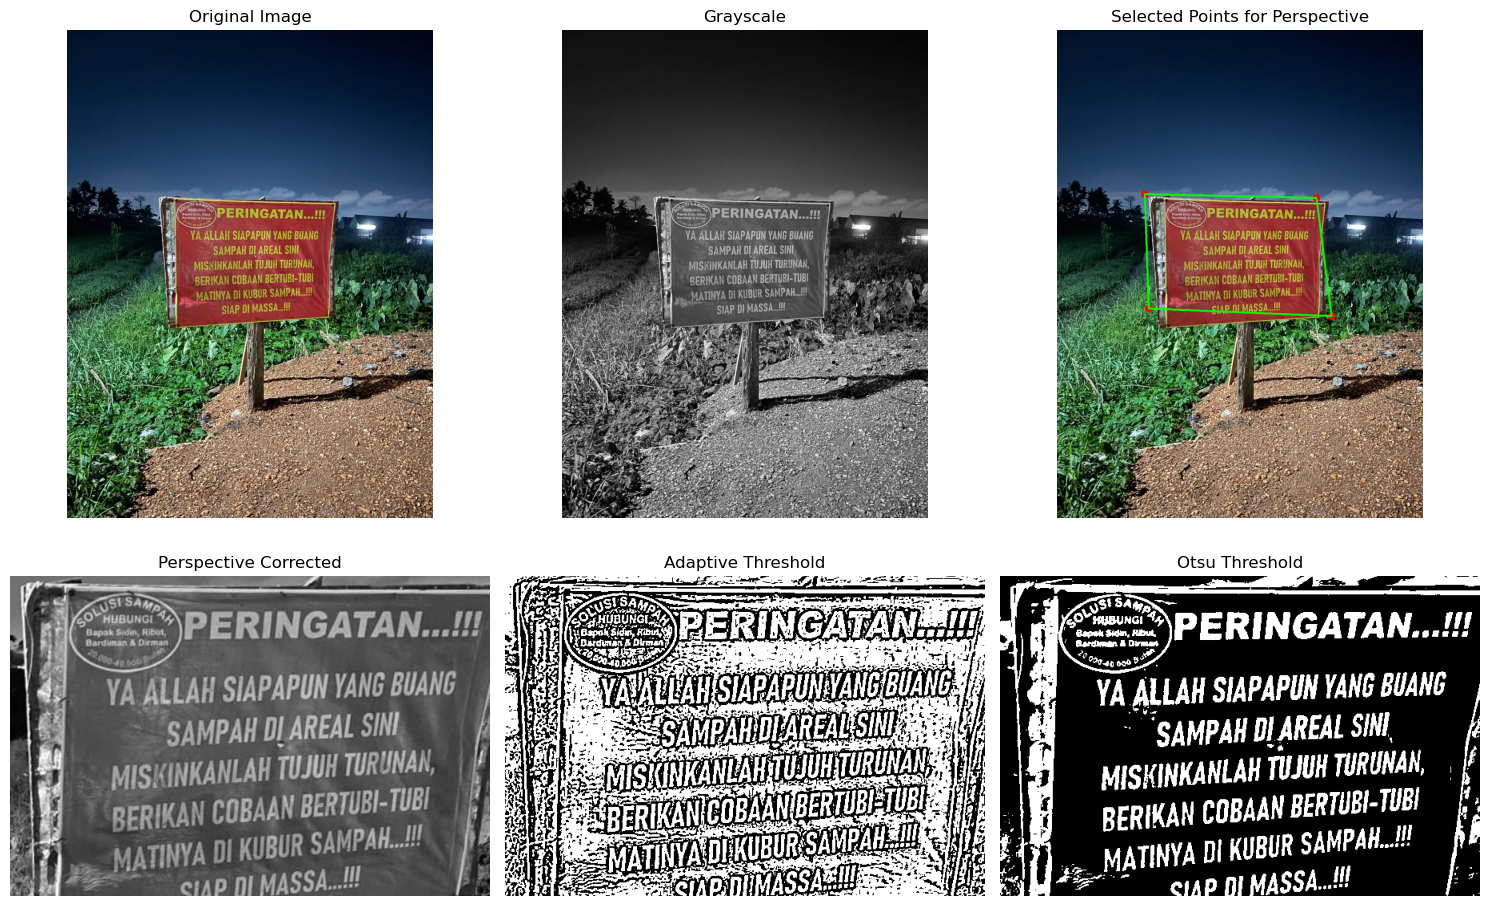

Perspective correction completed
Source points: [[230. 430.]
 [680. 440.]
 [720. 750.]
 [240. 730.]]
Destination size: 600x400


In [6]:
img_doc = cv2.imread(os.path.join('assets_ws4', 'image3.jpg'))
img_doc_rgb = cv2.cvtColor(img_doc, cv2.COLOR_BGR2RGB)

img_gray_doc = cv2.cvtColor(img_doc, cv2.COLOR_BGR2GRAY)

pts_src = np.array([[230, 430], [680, 440], [720, 750], [240, 730]], dtype=np.float32)

width = 600
height = 400
pts_dst = np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype=np.float32)

matrix = cv2.getPerspectiveTransform(pts_src, pts_dst)
img_perspective = cv2.warpPerspective(img_gray_doc, matrix, (width, height))

thresh_adaptive = cv2.adaptiveThreshold(
    img_perspective, 255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2)

_, thresh_otsu = cv2.threshold(img_perspective, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

img_doc_copy = img_doc_rgb.copy()
for point in pts_src:
    cv2.circle(img_doc_copy, tuple(point.astype(int)), 10, (255, 0, 0), -1)
cv2.polylines(img_doc_copy, [pts_src.astype(int)], True, (0, 255, 0), 3)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img_doc_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_gray_doc, cmap='gray')
axes[0, 1].set_title('Grayscale')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_doc_copy)
axes[0, 2].set_title('Selected Points for Perspective')
axes[0, 2].axis('off')

axes[1, 0].imshow(img_perspective, cmap='gray')
axes[1, 0].set_title('Perspective Corrected')
axes[1, 0].axis('off')

axes[1, 1].imshow(thresh_adaptive, cmap='gray')
axes[1, 1].set_title('Adaptive Threshold')
axes[1, 1].axis('off')

axes[1, 2].imshow(thresh_otsu, cmap='gray')
axes[1, 2].set_title('Otsu Threshold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join('results_ws4', 'soal5_perspective_correction.png'), dpi=150, bbox_inches='tight')
plt.show()

cv2.imwrite(os.path.join('results_ws4', 'soal5_perspective.png'), img_perspective)
cv2.imwrite(os.path.join('results_ws4', 'soal5_adaptive_thresh.png'), thresh_adaptive)
cv2.imwrite(os.path.join('results_ws4', 'soal5_otsu_thresh.png'), thresh_otsu)

print("Perspective correction completed")
print(f"Source points: {pts_src}")
print(f"Destination size: {width}x{height}")

#### Penjelasan Soal 5

**Koreksi Perspektif dan Enhancement Citra:**

1. **Konversi Grayscale:**
   - Tahap preprocessing untuk menyederhanakan data dengan menghilangkan informasi warna
   - Mengurangi kompleksitas komputasi dan fokus pada struktur geometris objek
   - Memudahkan threshold dan edge detection pada tahap selanjutnya

2. **Transformasi Perspektif (Homografi):**
   - Menggunakan 4 titik manual pada sudut-sudut papan peringatan sebagai source points
   - Memetakan ke destination rectangle untuk mendapatkan tampilan frontal sejajar
   - `cv2.getPerspectiveTransform()` menghitung matriks transformasi 3x3
   - `cv2.warpPerspective()` menerapkan transformasi untuk mengoreksi distorsi perspektif
   - Hasil: Objek yang awalnya miring menjadi tegak lurus seperti difoto dari depan

3. **Perbandingan Thresholding:**

   **Adaptive Thresholding:**
   - Menggunakan threshold lokal yang berbeda untuk setiap region gambar
   - Cocok untuk gambar dengan pencahayaan tidak merata (seperti papan outdoor ini)
   - Parameter: block_size=11, C=2 untuk Gaussian-weighted neighborhood
   - **Dipilih karena:** Gambar memiliki gradient pencahayaan dari kiri ke kanan
   
   **Otsu Thresholding:**
   - Menghitung threshold global optimal berdasarkan histogram bimodal
   - Baik untuk gambar dengan pencahayaan uniform
   - Pada kasus ini kurang optimal karena background memiliki variasi pencahayaan tinggi

4. **Peningkatan Kualitas:**
   - Transformasi perspektif menghilangkan distorsi geometris
   - Adaptive thresholding meningkatkan kontras teks pada background yang bervariasi
   - Kombinasi kedua teknik menghasilkan output yang lebih jelas dan mudah dibaca
   - Berguna untuk aplikasi document scanning dan OCR preprocessing

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.

---

## Credit dan Referensi

**Bantuan AI:**
- Claude Code (Anthropic) - Untuk membantu struktur code dan debugging
- Bukti Percakapan: ![Referensi](referensi.png)

**Library yang Digunakan:**
- OpenCV (cv2) - Image processing dan computer vision
- NumPy - Array manipulation dan mathematical operations
- Matplotlib - Data visualization dan plotting

**Referensi:**
- OpenCV Documentation: https://docs.opencv.org/
- OpenCV Haar Cascade Face Detection
- Digital Image Processing Concepts

**GitHub Repository:**
[https://github.com/luciferdana/multimedia]

---

**Nama:** Ferdana Al-Hakim  
**NIM:** 122140012  
**Tanggal Pengerjaan:** 17 November 2024